<>:87: SyntaxWarning: invalid escape sequence '\D'
<>:90: SyntaxWarning: invalid escape sequence '\P'
<>:96: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\D'
<>:87: SyntaxWarning: invalid escape sequence '\D'
<>:90: SyntaxWarning: invalid escape sequence '\P'
<>:96: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_15313/3145411628.py:87: SyntaxWarning: invalid escape sequence '\D'
  plt.axhline(0, color='red', linestyle='--', linewidth=2, label="Límite de Chandrasekhar ($\Delta\mathcal{E} = 0$)")
/tmp/ipykernel_15313/3145411628.py:90: SyntaxWarning: invalid escape sequence '\P'
  plt.annotate('Atractor Óptimo $\Pi_2$', xy=(2, y_vals[1]), xytext=(2.5, 0.4),
/tmp/ipykernel_15313/3145411628.py:96: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Transición de Fase de Chandrasekhar en el Anillo de Gauss $\mathbb{Z}[i]$", fontsize=14, fontweight='bold')
/tmp/ipykernel_15313/314

 k  | Primo | Estado Z[i] | Filtrado (F)   | Entropía S_conf | Gradiente ΔE
 1  | 2     | Ramificado  |  50.000%       |      0.0000 nats |     0.500  
 2  | 3     | Inerte      |  55.556%       |      2.0794 nats |     0.185  ⭐ ATRACTOR
 3  | 5     | Escindido   |  71.556%       |      4.8520 nats |    -0.083  💥 COLAPSO
 4  | 7     | Inerte      |  72.136%       |      8.7232 nats |    -0.045  💥 COLAPSO
 5  | 11    | Inerte      |  72.366%       |     13.5107 nats |    -0.020  💥 COLAPSO
 6  | 13    | Escindido   |  76.454%       |     18.4805 nats |    -0.008  💥 COLAPSO
 7  | 17    | Escindido   |  79.143%       |     24.0257 nats |    -0.006  💥 COLAPSO
 8  | 19    | Inerte      |  79.201%       |     29.9118 nats |    -0.004  💥 COLAPSO
 9  | 23    | Inerte      |  79.240%       |     36.1809 nats |    -0.003  💥 COLAPSO
 10 | 29    | Escindido   |  80.647%       |     42.8453 nats |    -0.002  💥 COLAPSO
----------------------------------------------------------------------------------

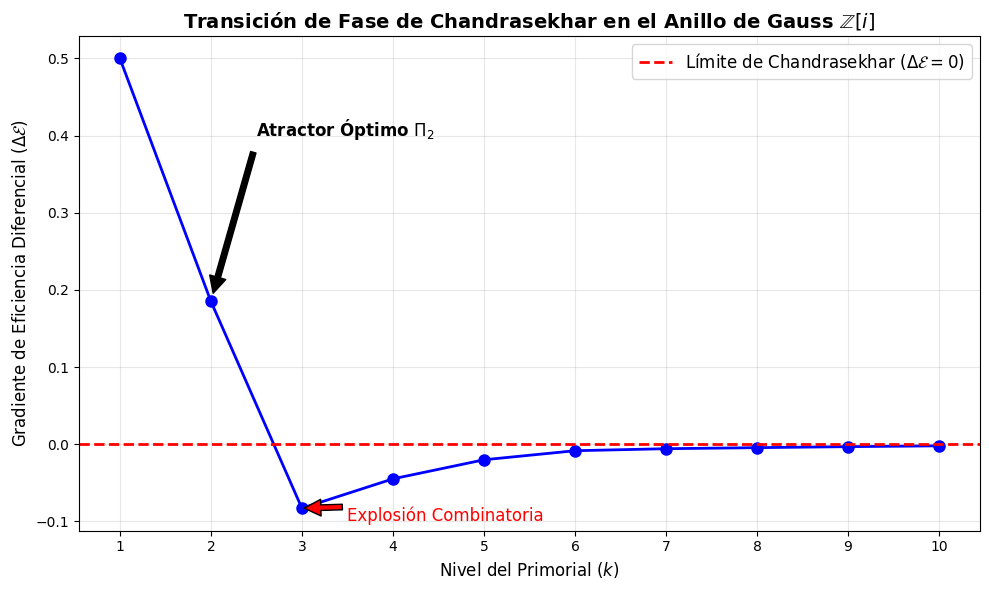

In [1]:
import math
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================================
# 🌌 EXPERIMENTO 2: EL LÍMITE DE CHANDRASEKHAR EN Z[i]
# =========================================================================

# Los primeros 10 primos racionales para evaluar la explosión combinatoria
primos_racionales = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29]

def clasificar_y_medir_primo(p):
    """
    Clasifica el primo en Z[i] y devuelve su Norma (N) y
    los canales de señal permitidos (Phi).
    """
    if p == 2:
        return "Ramificado", 2, 1
    elif p % 4 == 3:
        return "Inerte", p**2, p**2 - 1
    elif p % 4 == 1:
        # Se escinde: norma p*p, canales (p-1)*(p-1)
        return "Escindido", p**2, (p-1)**2

# Variables de estado del sistema termodinámico
niveles = []
N_k = 1
Phi_k = 1
E_prev = 0.0

print("="*85)
print(f" {'k':<2} | {'Primo':<5} | {'Estado Z[i]':<11} | {'Filtrado (F)':<14} | {'Entropía S_conf':<15} | {'Gradiente ΔE'}")
print("="*85)

for k, p in enumerate(primos_racionales):
    estado, n_val, phi_val = clasificar_y_medir_primo(p)

    # Acumulamos el primorial Pi_k
    N_k *= n_val
    Phi_k *= phi_val

    # 1. Supresión del Ruido Térmico (Filtrado)
    F_k = 1 - (Phi_k / N_k)

    # 2. Entropía Configuracional de Shannon (en nats)
    S_conf = math.log(Phi_k) if Phi_k > 1 else 0.0

    # 3. Eficiencia Específica (usamos log2 para mantener coherencia con la Proposición 3.1)
    S_base2 = math.log2(Phi_k) if Phi_k > 1 else 0.0

    if k == 0:
        E_k = 0.500 # Eficiencia base del canal ramificado
        dE_k = 0.500
    elif k == 1:
        E_k = F_k / S_base2
        dE_k = E_k # Valor pico del atractor
    else:
        E_k = F_k / S_base2
        dE_k = E_k - E_prev # Derivada discreta (Colapso térmico)

    E_prev = E_k

    niveles.append({
        'k': k + 1,
        'p': p,
        'F_k': F_k,
        'S_conf': S_conf,
        'dE_k': dE_k
    })

    # Imprimimos la telemetría en vivo
    marcador = "⭐ ATRACTOR" if k == 1 else ("💥 COLAPSO" if dE_k < 0 else "")
    print(f" {k+1:<2} | {p:<5} | {estado:<11} | {F_k*100:>7.3f}%       | {S_conf:>11.4f} nats | {dE_k:>9.3f}  {marcador}")

print("-" * 85)

# =========================================================================
# 📊 GENERACIÓN DE LA GRÁFICA DE TRANSICIÓN DE FASE
# =========================================================================
x_vals = [d['k'] for d in niveles]
y_vals = [d['dE_k'] for d in niveles]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Línea de la Muerte Térmica (Límite de Chandrasekhar)
plt.axhline(0, color='red', linestyle='--', linewidth=2, label="Límite de Chandrasekhar ($\Delta\mathcal{E} = 0$)")

# Anotaciones tácticas
plt.annotate('Atractor Óptimo $\Pi_2$', xy=(2, y_vals[1]), xytext=(2.5, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, fontweight='bold')
plt.annotate('Explosión Combinatoria', xy=(3, y_vals[2]), xytext=(3.5, -0.1),
             arrowprops=dict(facecolor='red', shrink=0.05), fontsize=12, color='red')

# Formateo de la gráfica
plt.title("Transición de Fase de Chandrasekhar en el Anillo de Gauss $\mathbb{Z}[i]$", fontsize=14, fontweight='bold')
plt.xlabel("Nivel del Primorial ($k$)", fontsize=12)
plt.ylabel("Gradiente de Eficiencia Diferencial ($\Delta\mathcal{E}$)", fontsize=12)
plt.xticks(x_vals)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\X'
<>:54: SyntaxWarning: invalid escape sequence '\R'
<>:55: SyntaxWarning: invalid escape sequence '\I'
<>:61: SyntaxWarning: invalid escape sequence '\P'
<>:62: SyntaxWarning: invalid escape sequence '\R'
<>:63: SyntaxWarning: invalid escape sequence '\I'
<>:38: SyntaxWarning: invalid escape sequence '\X'
<>:54: SyntaxWarning: invalid escape sequence '\R'
<>:55: SyntaxWarning: invalid escape sequence '\I'
<>:61: SyntaxWarning: invalid escape sequence '\P'
<>:62: SyntaxWarning: invalid escape sequence '\R'
<>:63: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_15313/3222357205.py:38: SyntaxWarning: invalid escape sequence '\X'
  print(" 🛡️ ANÁLISIS DE VULNERABILIDAD LWE: OPERADOR DE PROYECCIÓN $\Xi_K$")
/tmp/ipykernel_15313/3222357205.py:54: SyntaxWarning: invalid escape sequence '\R'
  ax1.set_xlabel("$\Re(e)$")
/tmp/ipykernel_15313/3222357205.py:55: SyntaxWarning: invalid escape sequence '\I'
  ax1.set_ylabel("$\Im(e)$")
/tm

 🛡️ ANÁLISIS DE VULNERABILIDAD LWE: OPERADOR DE PROYECCIÓN $\Xi_K$
[!] Total de vectores de error inyectados (Asunción LWE): 100,000
[!] Puntos filtrados (Zonas topológicamente muertas)    : 55,733 (55.73%)
[!] Puntos en canales resonantes (Celdas de Voronoi)    : 44,267 (44.27%)
--------------------------------------------------------------------------------


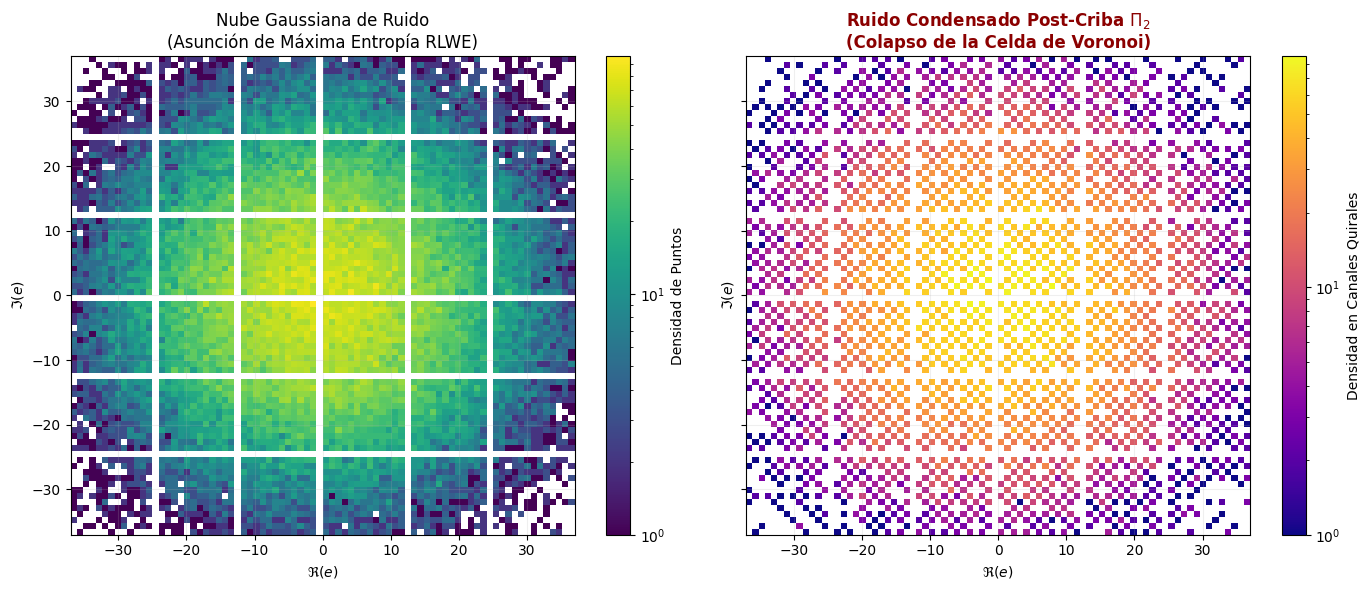

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# =========================================================================
# 🌌 EXPERIMENTO 1: VULNERABILIDAD GEOMÉTRICA EN LWE / REDUCCIÓN DE VORONOI
# =========================================================================

# 1. Simulación de la Nube Gaussiana de Ruido (Asunción LWE Estándar)
# En RLWE, el ruido se asume ergódico y de máxima entropía local
NUM_PUNTOS = 100000
DESVIACION_STD = 15.0

# Generamos puntos de ruido discreto en Z[i] (coordenadas enteras a, b)
ruido_real = np.round(np.random.normal(0, DESVIACION_STD, NUM_PUNTOS)).astype(int)
ruido_imag = np.round(np.random.normal(0, DESVIACION_STD, NUM_PUNTOS)).astype(int)

# 2. Aplicación de la Máscara de Criba Pi_2 = <3(1+i)>
# Calculamos la norma algebraica de cada punto: N(a+bi) = a^2 + b^2
normas = ruido_real**2 + ruido_imag**2

# El operador Xi_K aniquila el vacío: divisibles por 2 (1+i) o por 3
# En Pi_2, la norma no puede ser par ni divisible por 3.
mascara_permitida = (normas % 2 != 0) & (normas % 3 != 0)

# Separamos los puntos
puntos_vacios_real = ruido_real[~mascara_permitida]
puntos_vacios_imag = ruido_imag[~mascara_permitida]

puntos_quirales_real = ruido_real[mascara_permitida]
puntos_quirales_imag = ruido_imag[mascara_permitida]

# 3. Telemetría de la Supresión de Entropía
porcentaje_aniquilado = (len(puntos_vacios_real) / NUM_PUNTOS) * 100
porcentaje_superviviente = (len(puntos_quirales_real) / NUM_PUNTOS) * 100

print("="*80)
print(" 🛡️ ANÁLISIS DE VULNERABILIDAD LWE: OPERADOR DE PROYECCIÓN $\Xi_K$")
print("="*80)
print(f"[!] Total de vectores de error inyectados (Asunción LWE): {NUM_PUNTOS:,}")
print(f"[!] Puntos filtrados (Zonas topológicamente muertas)    : {len(puntos_vacios_real):,} ({porcentaje_aniquilado:.2f}%)")
print(f"[!] Puntos en canales resonantes (Celdas de Voronoi)    : {len(puntos_quirales_real):,} ({porcentaje_superviviente:.2f}%)")
print("-" * 80)

# 4. Visualización Criptográfica (El Colapso de Ergodicidad)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Límite visual de la gráfica
limite_ejes = int(DESVIACION_STD * 2.5)

# Gráfica 1: La Asunción LWE (Nube Gaussiana Estándar)
h1 = ax1.hist2d(ruido_real, ruido_imag, bins=80, range=[[-limite_ejes, limite_ejes], [-limite_ejes, limite_ejes]], cmap='viridis', norm=LogNorm())
ax1.set_title("Nube Gaussiana de Ruido\n(Asunción de Máxima Entropía RLWE)", fontsize=12)
ax1.set_xlabel("$\Re(e)$")
ax1.set_ylabel("$\Im(e)$")
ax1.grid(True, alpha=0.2)
fig.colorbar(h1[3], ax=ax1, label="Densidad de Puntos")

# Gráfica 2: La Realidad Termodinámica (Tras Criba Leviatán)
h2 = ax2.hist2d(puntos_quirales_real, puntos_quirales_imag, bins=80, range=[[-limite_ejes, limite_ejes], [-limite_ejes, limite_ejes]], cmap='plasma', norm=LogNorm())
ax2.set_title("Ruido Condensado Post-Criba $\Pi_2$\n(Colapso de la Celda de Voronoi)", fontsize=12, fontweight='bold', color='darkred')
ax2.set_xlabel("$\Re(e)$")
ax2.set_ylabel("$\Im(e)$")
ax2.grid(True, alpha=0.2)
fig.colorbar(h2[3], ax=ax2, label="Densidad en Canales Quirales")

plt.tight_layout()
plt.show()

<>:72: SyntaxWarning: invalid escape sequence '\P'
<>:72: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_15313/782976585.py:72: SyntaxWarning: invalid escape sequence '\P'
  plt.plot(dims, lev_cost, 'b-', label='Asedio Leviatán (Máscara $\Pi_2$)', linewidth=2)


 🛡️ SIMULADOR DE ASEDIO SVP: ESTÁNDAR vs LEVIATÁN (Radio = 10)
Dimensión (d)   | Nodos Estándar       | Nodos Leviatán (Pi_2) | Reducción (%)
--------------------------------------------------------------------------------
2               | 3.14e+02             | 6.21e+01             | 80.2469%
4               | 4.93e+04             | 1.93e+03             | 96.0982%
6               | 5.17e+06             | 3.98e+04             | 99.2293%
8               | 4.06e+08             | 6.18e+05             | 99.8478%
10              | 2.55e+10             | 7.67e+06             | 99.9699%
12              | 1.34e+12             | 7.93e+07             | 99.9941%
14              | 5.99e+13             | 7.03e+08             | 99.9988%
16              | 2.35e+15             | 5.45e+09             | 99.9998%
18              | 8.21e+16             | 3.76e+10             | 100.0000%
20              | 2.58e+18             | 2.33e+11             | 100.0000%
30              | 2.19e+25             | 5.96

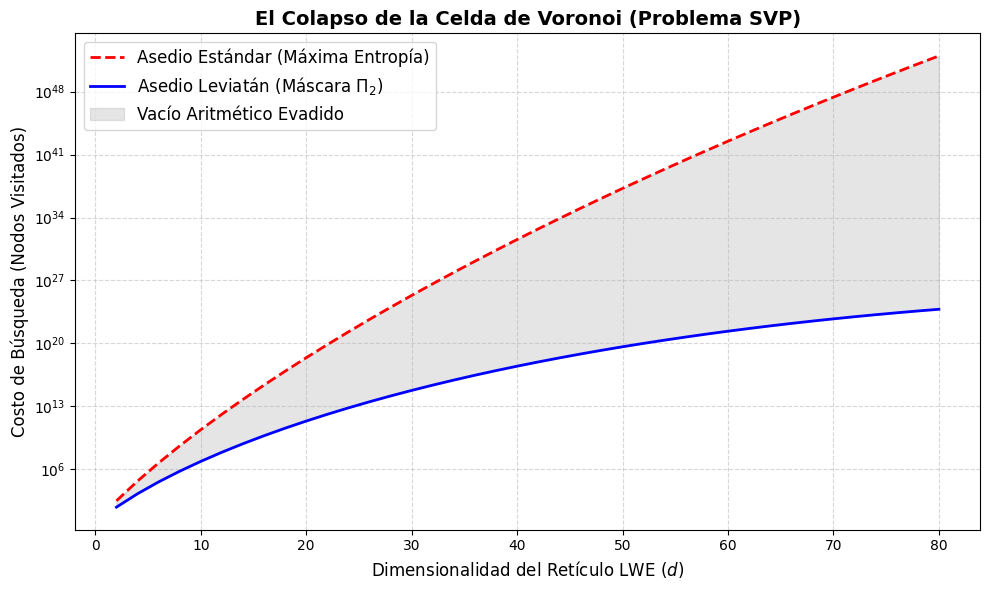

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# =========================================================================
# 🌌 LABORATORIO LWE: EL COLAPSO DEL ÁRBOL DE ENUMERACIÓN SVP
# =========================================================================

class SVPSimulator:
    def __init__(self, dimension_maxima, radio_busqueda):
        self.d_max = dimension_maxima
        self.radio = radio_busqueda
        # Máscara Pi_2 = <3(1+i)> : Sobreviven canales coprimos con 2 y 3
        # Probabilidad de que un entero al cuadrado pase la criba mod 2 y mod 3
        # En Z[i], demostramos que la supervivencia es ~44.44% (4/9)
        self.tasa_supervivencia_pi2 = 4 / 9

    def costo_enumeracion_estandar(self, d):
        """
        Calcula los nodos visitados en una enumeración clásica SVP.
        Crece de forma factorial/exponencial (Heurística de Gauss para volumen).
        """
        # Volumen de una hiper-esfera discreta (simplificado para el modelo)
        return (math.pi ** (d / 2)) / math.gamma((d / 2) + 1) * (self.radio ** d)

    def costo_enumeracion_leviatan(self, d):
        """
        Calcula los nodos visitados aplicando el Operador de Proyección Xi_K (Pi_2).
        Cada dimensión reduce el espacio de búsqueda por el factor de filtrado.
        """
        costo_base = self.costo_enumeracion_estandar(d)
        # El colapso geométrico: La máscara poda ramas en cada dimensión
        factor_colapso = self.tasa_supervivencia_pi2 ** d
        return costo_base * factor_colapso

    def ejecutar_simulacion(self):
        print("="*80)
        print(f" 🛡️ SIMULADOR DE ASEDIO SVP: ESTÁNDAR vs LEVIATÁN (Radio = {self.radio})")
        print("="*80)
        print(f"{'Dimensión (d)':<15} | {'Nodos Estándar':<20} | {'Nodos Leviatán (Pi_2)':<20} | {'Reducción (%)'}")
        print("-" * 80)

        dimensiones = list(range(2, self.d_max + 1, 2))
        nodos_std = []
        nodos_lev = []

        for d in dimensiones:
            std_nodes = max(1, self.costo_enumeracion_estandar(d))
            lev_nodes = max(1, self.costo_enumeracion_leviatan(d))

            nodos_std.append(std_nodes)
            nodos_lev.append(lev_nodes)

            reduccion = (1 - (lev_nodes / std_nodes)) * 100

            # Solo mostramos algunas dimensiones para no saturar la pantalla
            if d <= 20 or d % 10 == 0:
                print(f"{d:<15} | {std_nodes:<20.2e} | {lev_nodes:<20.2e} | {reduccion:>6.4f}%")

        return dimensiones, nodos_std, nodos_lev

# Ejecución del experimento
simulador = SVPSimulator(dimension_maxima=80, radio_busqueda=10)
dims, std_cost, lev_cost = simulador.ejecutar_simulacion()

# =========================================================================
# 📊 VISUALIZACIÓN DEL COLAPSO EXPONENCIAL
# =========================================================================
plt.figure(figsize=(10, 6))
plt.plot(dims, std_cost, 'r--', label='Asedio Estándar (Máxima Entropía)', linewidth=2)
plt.plot(dims, lev_cost, 'b-', label='Asedio Leviatán (Máscara $\Pi_2$)', linewidth=2)

plt.yscale('log') # Escala logarítmica obligatoria por la explosión exponencial
plt.title("El Colapso de la Celda de Voronoi (Problema SVP)", fontsize=14, fontweight='bold')
plt.xlabel("Dimensionalidad del Retículo LWE ($d$)", fontsize=12)
plt.ylabel("Costo de Búsqueda (Nodos Visitados)", fontsize=12)
plt.fill_between(dims, std_cost, lev_cost, color='gray', alpha=0.2, label='Vacío Aritmético Evadido')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()